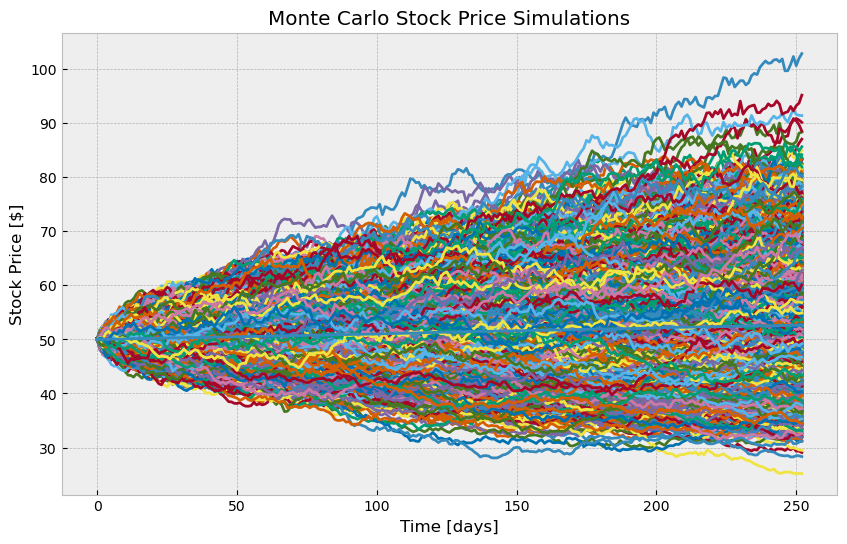

Prediction for future stock price: $ 52.62


/tmp/ipykernel_18748/3149515400.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Prediction for future stock price: $ %.2f" %simulation_data['mean'].tail(1))


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("bmh")

NUM_OF_SIMULATIONS = 10000

def stock_monte_carlo(S0, mu, sigma, N=252):
    result = []
    # number of simulations - possible S(t) realizations (of the process)
    for _ in range(NUM_OF_SIMULATIONS):
        prices = [S0]
        for _ in range(N):
            # we simulate the change day by day (t=1)
            stock_price = prices[-1] * np.exp((mu - 0.5 * sigma ** 2) + 
                                            sigma * np.random.normal())
            prices.append(stock_price)
        result.append(prices)
    
    # Create DataFrame from results
    simulation_data = pd.DataFrame(result).T  # Transpose to have time as rows
    simulation_data['mean'] = simulation_data.mean(axis=1)
    
    # Plot the simulations
    plt.figure(figsize=(10, 6))
    plt.plot(simulation_data)
    #plt.plot(simulation_data["mean"], "k--")
    plt.title('Monte Carlo Stock Price Simulations')
    plt.xlabel('Time [days]')
    plt.ylabel('Stock Price [$]')
    plt.grid(True)
    plt.savefig("./figs/MCStocks/mc_gbm_bodoh.png", dpi=300)
    plt.show()
    print("Prediction for future stock price: $ %.2f" %simulation_data['mean'].tail(1))
if __name__ == "__main__":
    stock_monte_carlo(50, 0.0002, 0.01)